<a href="https://colab.research.google.com/github/M90X-2/IT480-FA26/blob/main/Lab2_CNN_PetFinder_Starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2: CNN for Image Classification (PetFinder)

**Name:** Maximilian Vogel (no lab partner)

This notebook has no starter code. Each section below tells you what to build and what questions to answer in your own words, but the code itself is yours to write. Use the CNN Fundamentals lecture and Lab 1 as your reference for syntax, not as something to copy from.

**Submission:** GitHub repo URL + this notebook's URL on Canvas.

## Setup

Clone the course repo (or your fork) to access the dataset, then import the libraries you expect to need. You will likely want `pandas`, `numpy`, `os`, image-loading tools (for example `PIL.Image`), `matplotlib`, `tensorflow`, and evaluation tools from `sklearn`. Add imports as you go, you don't need to guess all of them up front.

In [12]:
# Clone the repo to access the data (only needs to run once per Colab session)
# !git clone <your-fork-url>


In [13]:
# Your imports here
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical

In [14]:
# Load train.csv here

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [15]:
# Write your image-loading function here

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [16]:
# Build X and y, then split into train/test here
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

---
## Part B: Build a CNN From Scratch

**What to decide, and be ready to justify:**
- How many Conv2D and MaxPooling2D layers will you use?
- How many filters at each layer, and how does that number change as you go deeper?
- What kernel size will you use, and why?
- What does your Dense classifier head look like after the Flatten layer?


Write your architecture below, then write one paragraph justifying every choice, using the conventions from lecture (filters growing with depth, 3x3 kernels, funnel-shaped Dense layers, and so on).

In [17]:
# Build your CNN model here
model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])


In [18]:
# Compile your model here
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

*Your architecture justification (one paragraph):*

The model uses three layers of conv2d and maxpooling2d so that the spacial dimensions are progressively downsized while still extracting the features. The filters double between each layer, starting at 32, then 64, and finally 128. I used a 3x3 kernel size because it is standard and captures the spatial hierarchies and edges without a lot of computational overhead. I pass it through a 64 unit Dense layer then finally through a 10 unit softmax dense layer.


---
## Part C: Train and Diagnose

**What to do:**
1. Train your model, saving the history.
2. Plot training vs. validation loss and accuracy.
3. Diagnose the fit: good fit, overfitting, or underfitting? Point to specific evidence from your own curve.
4. Evaluate on the test set and report accuracy.

In [19]:
# Train your model here (save the result as `history`)
history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.2)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.7783 - loss: 0.6064 - val_accuracy: 0.8298 - val_loss: 0.4599
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 21ms/step - accuracy: 0.8535 - loss: 0.4047 - val_accuracy: 0.8632 - val_loss: 0.3745
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 33s 22ms/step - accuracy: 0.8727 - loss: 0.3445 - val_accuracy: 0.8543 - val_loss: 0.3921
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.8852 - loss: 0.3094 - val_accuracy: 0.8823 - val_loss: 0.3226
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 33s 22ms/step - accuracy: 0.8974 - loss: 0.2774 - val_accuracy: 0.8881 - val_loss: 0.3172
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 21ms/step - accuracy: 0.9066 - loss: 0.2528 - val_accuracy: 0.8888 - val_loss: 0.3062
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 21ms/step - accuracy: 0.9140 - loss: 0.2308 - val_accuracy: 0.8858 - val_loss: 0.3149
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 33s 22ms/step - accuracy: 0.9217 -

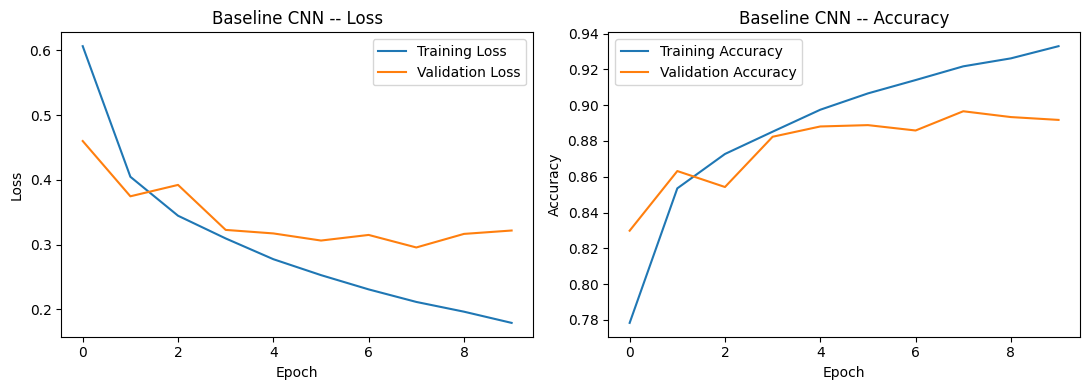

In [20]:
# Plot training vs. validation loss and accuracy here
import matplotlib.pyplot as plt

def plot_history(history, title, show_accuracy=False):
    if show_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(history.history["loss"], label="Training Loss")
        axes[0].plot(history.history["val_loss"], label="Validation Loss")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
        axes[0].set_title(title + " -- Loss")

        axes[1].plot(history.history["accuracy"], label="Training Accuracy")
        axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
        axes[1].set_title(title + " -- Accuracy")
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(6, 4))
        plt.plot(history.history["loss"], label="Training Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss (MSE, scaled)"); plt.title(title); plt.legend()
        plt.show()

plot_history(history, "Baseline CNN", show_accuracy=True)

*Your fit diagnosis, with specific evidence from your curve:*
The model is mildly overfitting as seen with the validation loss starting below the training loss then increasing around Epoch 0.5 and going above the training loss. While the training loss continues to decrease smoothly.



In [21]:
# Evaluate on the test set and report accuracy here
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)

print(f"\nTest Accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8869 - loss: 0.3491

Test Accuracy: 0.8869


---
## Part D: Improve the Model

Choose **one** path, based on what Part C showed you.

**If your baseline overfit:** apply Dropout, Early Stopping, or both, the same tools from Assignment 1, to your own CNN.

**If your baseline did not overfit, or you want to push accuracy further:** use Keras Tuner to search over at least 2 hyperparameters of your choosing. Keep the same test-set discipline from Assignment 1: tuning only touches training and validation data, the test set is touched once, at the end.

State which path you chose and why, before you start building it.

*Which path are you taking, and why:*

My baseline overfit so I am deciding to add Dropout and Early Stopping to the model to try and smooth out the learning curve and keep the validation loss decreasing alongside the training loss.


In [22]:
# Build your improved model here
final_history = tf.keras.Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Dropout(0.2),

    Flatten(),
    Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.4),

    Dense(10, activation='softmax')
])

early_stop = tf.keras.callbacks.EarlyStopping(
  monitor="val_loss",
  patience=5,
  restore_best_weights=True
)

final_history.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

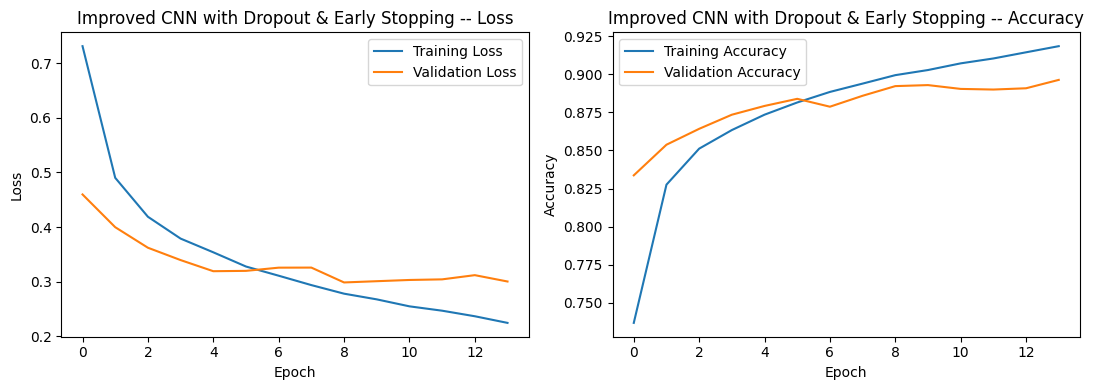

In [23]:
# Train your improved model here
history = final_history.fit(
  x_train, y_train,
  validation_split=0.2,
  epochs=100,
  callbacks=[early_stop],
  verbose=0
)

plot_history(history, "Improved CNN with Dropout & Early Stopping", show_accuracy=True)

In [24]:
test_loss, test_accuracy = final_history.evaluate(x_test, y_test, verbose=1)

print(f"\nTest Accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8880 - loss: 0.3198

Test Accuracy: 0.8880


---
## Part E: Compare and Evaluate

Fill in your own results:

| | Baseline CNN | Improved CNN |
|---|---|---|
| Test accuracy |88.69%|88.80%|
| Fit pattern (good/over/under) |Over |Over but less |
| What changed |N/A|Added two layers of dropout and Early stopping|

Report a confusion matrix for your improved model. Are Dogs or Cats more often misclassified? Do you have a guess as to why, based on looking at a few misclassified photos directly?

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


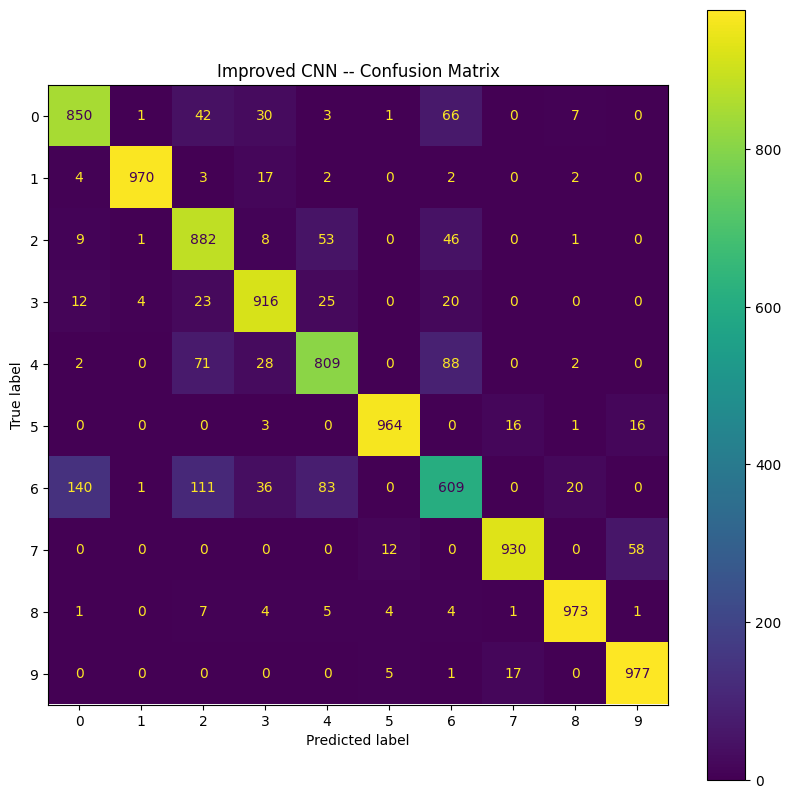

In [29]:
# Evaluate your improved model and build a confusion matrix here
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

final_probs = final_history.predict(x_test)
final_preds = np.argmax(final_probs, axis=1)

y_true = np.argmax(y_test, axis=1)

cm_f = confusion_matrix(y_true, final_preds)

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_f)
disp.plot(ax=ax)

plt.title("Improved CNN -- Confusion Matrix")
plt.show()

*Your discussion of the confusion matrix:*
Overall the model works well and correctly identifies most classes between 800 and 970 times. However, it noticeably struggles with label 6 dropping to just 609 correct predictions. You can see the model struggles to identify class 6 often and even misidentifies label 6 with other classes as well.


---
## Part F: Look at Your Mistakes

Pull 3 to 5 images your model got wrong and display them. Write 2 to 3 sentences: is there anything visually in common among the photos your model struggled with, unusual angles, poor lighting, multiple animals in frame, something else?

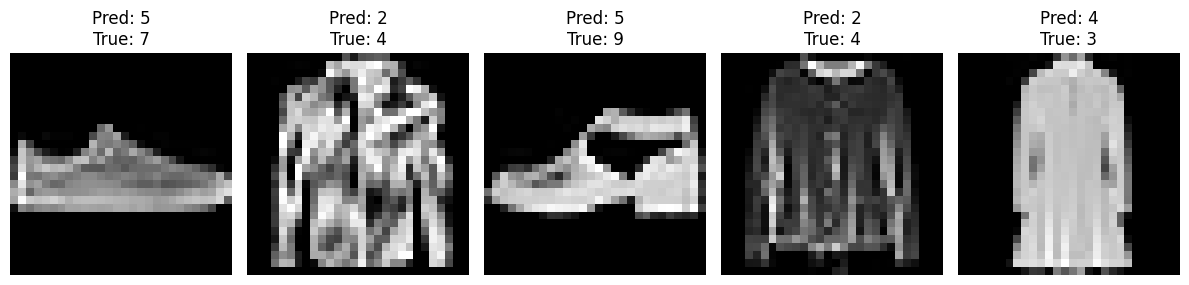

In [32]:
# Find and display misclassified images here

import numpy as np
import matplotlib.pyplot as plt

misclassified_idx = np.where(y_true != final_preds)[0]

plt.figure(figsize=(12, 6))

for j in range(5):
    ax = plt.subplot(1, 5, j + 1)

    idx = misclassified_idx[j]

    plt.imshow(x_test[idx].reshape(28, 28), cmap="gray")

    plt.title(f"Pred: {final_preds[idx]}\nTrue: {y_true[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

*Your observations about the misclassified images:*
The model tended to struggle with different types of shoes and shirts with longer sleeves. This is most likely due to the lower resolution images making it hard to identify small details that separate them from each other. The images having very similar silhouettes could easily cause for misidentification.



---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.